# 04 — Limpieza estadística de métricas de rendimiento

**Objetivo**: detectar y excluir instancias de **no participación o participación residual** en tareas de entrenamiento, manteniendo un enfoque **conservador** y **metodológicamente defendible** para un TFG.

### Contexto del pipeline

| Notebook | Fase | Estado |
|:---|:---|:---|
| 01 | Limpieza de negocio (duplicados, NaN, IDs) | ✅ |
| 02 | Selección de Variables Dependientes | ✅ |
| 03 | Creación de métricas derivadas y normalización | ✅ |
| **04** | **Limpieza estadística de métricas** | 🔄 ← este notebook |

### Principios metodológicos

1. **No eliminar valores extremos altos**: representan rendimiento real de élite.
2. **Criterios basados en percentiles dinámicos**, nunca hardcodeados.
3. **Diagnóstico antes de acción**: cada filtro se muestra, evalúa y compara antes de aplicarse.
4. **Compatibilidad** con análisis posteriores (ANOVA, GLMM, ICC).

## 1 · Carga y funciones auxiliares

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Estilo global ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

PALETTE = {
    "azul":    "#1565C0",
    "rojo":    "#C62828",
    "verde":   "#2E7D32",
    "naranja": "#EF6C00",
    "gris":    "#616161",
    "morado":  "#6A1B9A",
}

# ── Mapeo de nombres cortos a nombres reales de columna ──
COL = {
    "TotalTouches":    "Total Touches (#)",
    "TouchesPerMin":   "Total Touches / min",
    "PassesOver15ms":  "Golpeos +15 m/s",
    "Passes15PerMin":  "Golpeos +15 m/s / min",
    "DistanceCovered": "Distance Covered (m)",
    "DistPerMin":      "Distance Covered (m) / min",
    "HIDCovered":      "High Intensity Distance (20 km/h)",
    "HIDPerMin":       "High Intensity Distance (20 km/h) / min",
}

VD_ABS = [COL["TotalTouches"], COL["PassesOver15ms"], COL["DistanceCovered"], COL["HIDCovered"]]
VD_MIN = [COL["TouchesPerMin"], COL["Passes15PerMin"], COL["DistPerMin"], COL["HIDPerMin"]]
VD_ALL = VD_ABS + VD_MIN

# ── Carga del dataset ──
df = pd.read_excel("../Datos/Matriz_V2.xlsx")
print(f"✅ Matriz_V2 cargada — {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Matriz_V2 cargada — 4,621 filas × 19 columnas


In [2]:
# ═══════════════════════════════════════════════════════════
# FUNCIONES REUTILIZABLES
# ═══════════════════════════════════════════════════════════

def compute_percentiles(serie: pd.Series, qs=(0.01, 0.05, 0.10, 0.25, 0.50)) -> pd.Series:
    """Devuelve percentiles dinámicos de una serie."""
    return serie.quantile(list(qs)).rename("valor")


def detect_outliers_iqr(serie: pd.Series, k: float = 1.5) -> pd.Series:
    """Devuelve máscara booleana de outliers por IQR (solo superiores)."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + k * iqr
    lower = q1 - k * iqr
    return (serie > upper) | (serie < lower), {"Q1": q1, "Q3": q3, "IQR": iqr,
                                                 "lower": lower, "upper": upper}


def detect_outliers_zscore(serie: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Devuelve máscara booleana de outliers por z-score (|z| > threshold)."""
    z = np.abs(stats.zscore(serie, nan_policy="omit"))
    return z > threshold, z


def summarize_before_after(df_before: pd.DataFrame, df_after: pd.DataFrame,
                           cols: list, label_antes="Antes", label_despues="Después") -> pd.DataFrame:
    """Tabla comparativa antes/después con Media, SD, CV para cada columna."""
    rows = []
    for col in cols:
        for label, data in [(label_antes, df_before), (label_despues, df_after)]:
            s = data[col]
            rows.append({
                "Variable": col,
                "Fase": label,
                "N": len(s),
                "Media": s.mean(),
                "SD": s.std(),
                "CV (%)": (s.std() / s.mean() * 100) if s.mean() != 0 else np.nan,
            })
    result = pd.DataFrame(rows).round(2)
    return result.set_index(["Variable", "Fase"])


print("✅ Funciones definidas: compute_percentiles, detect_outliers_iqr, detect_outliers_zscore, summarize_before_after")

✅ Funciones definidas: compute_percentiles, detect_outliers_iqr, detect_outliers_zscore, summarize_before_after


## 2 · Criterio principal — Detección de no participación por toques

Un jugador que registra valores simultáneamente bajos en **Total Touches** y **Touches / min** probablemente no participó activamente en la tarea (p. ej., estaba en recuperación, llegó tarde, salió temprano, etc.).

**Criterio**: excluir instancias que estén **simultáneamente** por debajo del percentil 5 en ambas variables. Al exigir la conjunción de ambas condiciones, el criterio es conservador y reduce falsos positivos.

In [3]:
# ── 2.1 Percentiles de las variables de toques ──
print("═" * 60)
print("  PERCENTILES — Total Touches (#)")
print("═" * 60)
print(compute_percentiles(df[COL["TotalTouches"]]))

print(f"\n{'═' * 60}")
print("  PERCENTILES — Total Touches / min")
print("═" * 60)
print(compute_percentiles(df[COL["TouchesPerMin"]]))

# Valores de corte (p05)
q05_touches   = df[COL["TotalTouches"]].quantile(0.05)
q05_tpm       = df[COL["TouchesPerMin"]].quantile(0.05)

print(f"\n🔑 Umbrales p05:")
print(f"   Total Touches (#)   < {q05_touches}")
print(f"   Total Touches / min < {q05_tpm:.4f}")

════════════════════════════════════════════════════════════
  PERCENTILES — Total Touches (#)
════════════════════════════════════════════════════════════
0.01     0.0
0.05     3.0
0.10     8.0
0.25    16.0
0.50    28.0
Name: valor, dtype: float64

════════════════════════════════════════════════════════════
  PERCENTILES — Total Touches / min
════════════════════════════════════════════════════════════
0.01    0.000000
0.05    0.300000
0.10    0.615385
0.25    1.166667
0.50    2.000000
Name: valor, dtype: float64

🔑 Umbrales p05:
   Total Touches (#)   < 3.0
   Total Touches / min < 0.3000


════════════════════════════════════════════════════════════
  DESGLOSE DE INSTANCIAS POR DEBAJO DE p05
════════════════════════════════════════════════════════════
  Total Touches < p05 (total):         196  (4.24%)
  Touches/min   < p05 (total):         230  (4.98%)
  ─────────────────────────────────────────────
  Solo Touches < p05 (no TPM):          21  (0.45%)
  Solo Touches/min < p05 (no Abs):      55  (1.19%)
  AMBOS < p05 (criterio aplicado):     175  (3.79%) ← se eliminan
  Cualquiera < p05 (unión OR):         251  (5.43%)
════════════════════════════════════════════════════════════


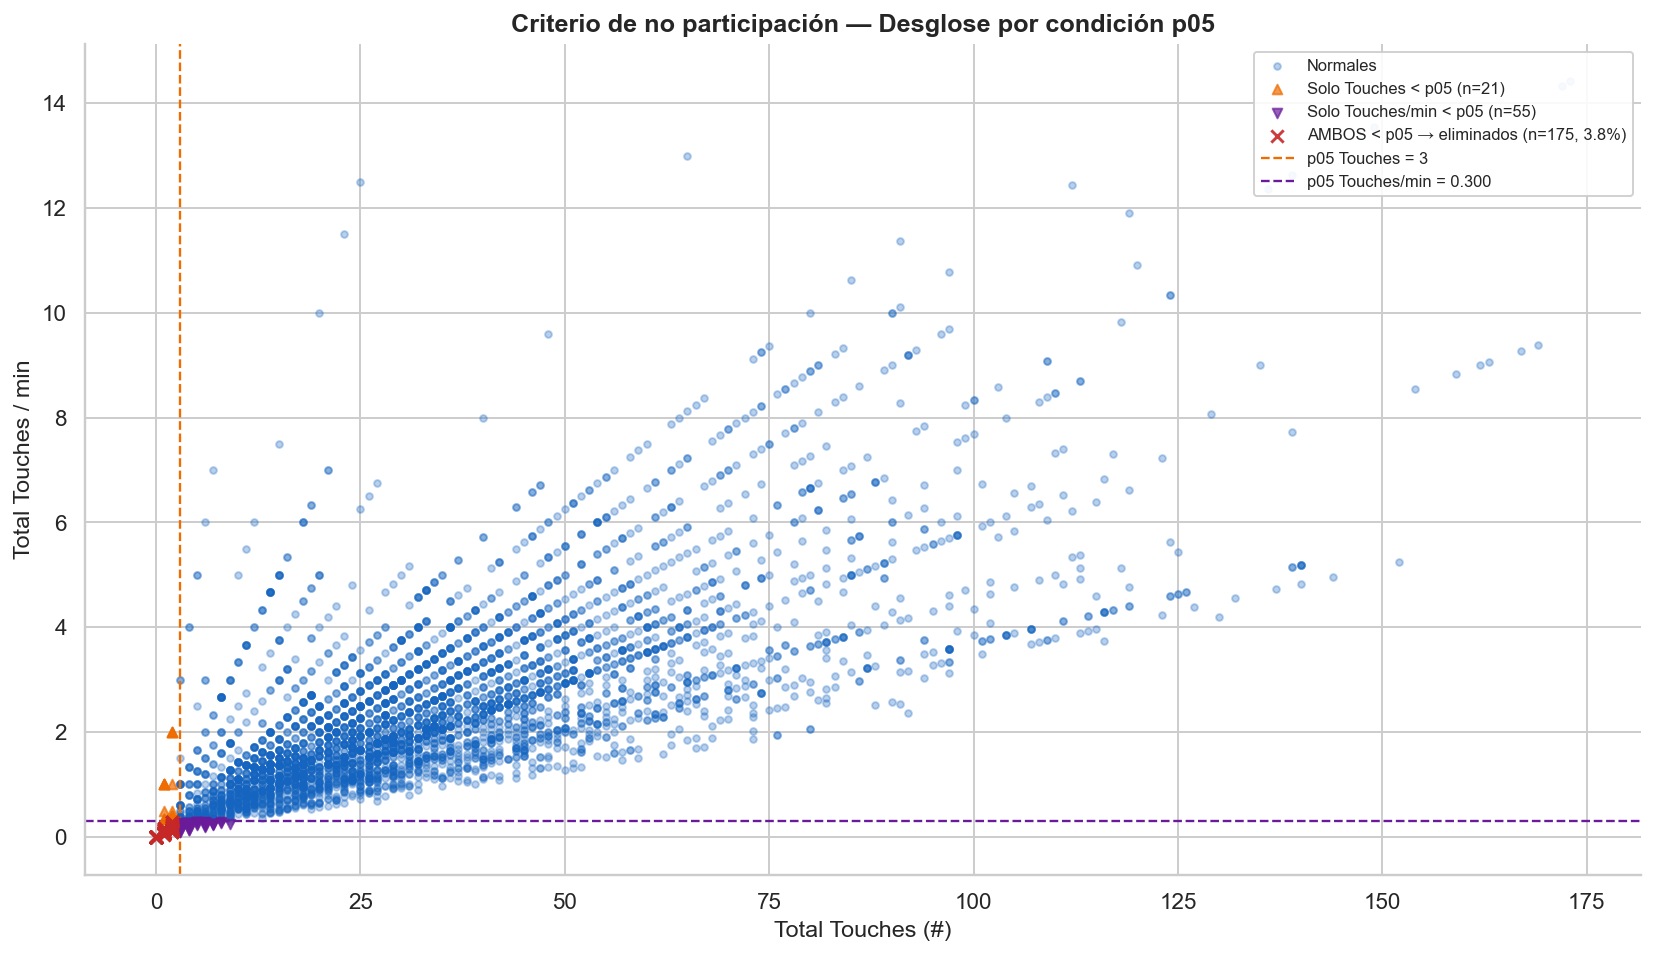


💡 Solo 175 instancias cumplen AMBAS condiciones simultáneamente.
   El criterio AND es 76 instancias más conservador que el OR.


In [4]:
# ── 2.2 Scatter: TotalTouches vs TouchesPerMin — diagnóstico visual ──
mask_low_touches = (df[COL["TotalTouches"]] < q05_touches)
mask_low_tpm     = (df[COL["TouchesPerMin"]] < q05_tpm)
mask_no_part     = mask_low_touches & mask_low_tpm  # conjunción = conservador

# ── Desglose detallado de instancias por debajo de p05 ──
n_only_touches = (mask_low_touches & ~mask_low_tpm).sum()
n_only_tpm     = (mask_low_tpm & ~mask_low_touches).sum()
n_both         = mask_no_part.sum()
n_either       = (mask_low_touches | mask_low_tpm).sum()

print("═" * 60)
print("  DESGLOSE DE INSTANCIAS POR DEBAJO DE p05")
print("═" * 60)
print(f"  Total Touches < p05 (total):       {mask_low_touches.sum():>5}  ({mask_low_touches.sum()/len(df)*100:.2f}%)")
print(f"  Touches/min   < p05 (total):       {mask_low_tpm.sum():>5}  ({mask_low_tpm.sum()/len(df)*100:.2f}%)")
print(f"  ─────────────────────────────────────────────")
print(f"  Solo Touches < p05 (no TPM):       {n_only_touches:>5}  ({n_only_touches/len(df)*100:.2f}%)")
print(f"  Solo Touches/min < p05 (no Abs):   {n_only_tpm:>5}  ({n_only_tpm/len(df)*100:.2f}%)")
print(f"  AMBOS < p05 (criterio aplicado):   {n_both:>5}  ({n_both/len(df)*100:.2f}%) ← se eliminan")
print(f"  Cualquiera < p05 (unión OR):       {n_either:>5}  ({n_either/len(df)*100:.2f}%)")
print("═" * 60)

n_flag   = mask_no_part.sum()
pct_flag = n_flag / len(df) * 100

# ── Gráfico con 4 categorías ──
mask_only_t  = mask_low_touches & ~mask_low_tpm
mask_only_tp = mask_low_tpm & ~mask_low_touches
mask_normal  = ~mask_low_touches & ~mask_low_tpm

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df.loc[mask_normal, COL["TotalTouches"]],
           df.loc[mask_normal, COL["TouchesPerMin"]],
           s=12, alpha=0.30, color=PALETTE["azul"], label="Normales", zorder=2)

ax.scatter(df.loc[mask_only_t, COL["TotalTouches"]],
           df.loc[mask_only_t, COL["TouchesPerMin"]],
           s=25, alpha=0.7, color=PALETTE["naranja"], marker="^",
           label=f"Solo Touches < p05 (n={n_only_touches})", zorder=3)

ax.scatter(df.loc[mask_only_tp, COL["TotalTouches"]],
           df.loc[mask_only_tp, COL["TouchesPerMin"]],
           s=25, alpha=0.7, color=PALETTE["morado"], marker="v",
           label=f"Solo Touches/min < p05 (n={n_only_tpm})", zorder=3)

ax.scatter(df.loc[mask_no_part, COL["TotalTouches"]],
           df.loc[mask_no_part, COL["TouchesPerMin"]],
           s=40, alpha=0.90, color=PALETTE["rojo"], marker="x", linewidths=1.5,
           label=f"AMBOS < p05 → eliminados (n={n_both}, {pct_flag:.1f}%)", zorder=4)

ax.axvline(q05_touches, color=PALETTE["naranja"], ls="--", lw=1.2,
           label=f"p05 Touches = {q05_touches:.0f}")
ax.axhline(q05_tpm, color=PALETTE["morado"], ls="--", lw=1.2,
           label=f"p05 Touches/min = {q05_tpm:.3f}")

ax.set_xlabel("Total Touches (#)", fontsize=12)
ax.set_ylabel("Total Touches / min", fontsize=12)
ax.set_title("Criterio de no participación — Desglose por condición p05", fontsize=13)
ax.legend(fontsize=8.5, loc="upper right", framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\n💡 Solo {n_both} instancias cumplen AMBAS condiciones simultáneamente.")
print(f"   El criterio AND es {n_either - n_both} instancias más conservador que el OR.")

## 3 · Detección de outliers superiores (sin eliminación)

Se detectan outliers superiores por **IQR** (k = 1.5) y **z-score** (|z| > 3) en las 4 VD absolutas. **No se eliminan**: representan rendimiento extremo pero real. Se reportan para transparencia y para evaluar su impacto en análisis posteriores.

In [5]:
# ── 3.1 Reporte de outliers superiores por IQR y z-score ──
print("═" * 70)
print("  OUTLIERS SUPERIORES — Reporte informativo (NO se eliminan)")
print("═" * 70)

outlier_report = []
for col in VD_ABS:
    mask_iqr, info = detect_outliers_iqr(df[col])
    mask_z, _      = detect_outliers_zscore(df[col])

    # Solo superiores
    n_iqr_upper = (df[col] > info["upper"]).sum()
    n_z_upper   = ((df[col] - df[col].mean()) / df[col].std() > 3).sum()

    outlier_report.append({
        "Variable": col,
        "IQR upper": f"{info['upper']:.1f}",
        "n > IQR upper": n_iqr_upper,
        "% > IQR upper": round(n_iqr_upper / len(df) * 100, 2),
        "n |z| > 3 (sup)": n_z_upper,
        "% |z| > 3 (sup)": round(n_z_upper / len(df) * 100, 2),
    })

df_outliers = pd.DataFrame(outlier_report)
display(df_outliers)

print("\n⚠️  Estos outliers NO se eliminan — representan rendimiento real.")

══════════════════════════════════════════════════════════════════════
  OUTLIERS SUPERIORES — Reporte informativo (NO se eliminan)
══════════════════════════════════════════════════════════════════════


,Variable,IQR upper,n > IQR upper,% > IQR upper,n |z| > 3 (sup),% |z| > 3 (sup)
0,Total Touches (#),91.0,180,3.90,71,1.54
1,Golpeos +15 m/s,7.5,249,5.39,70,1.51
2,Distance Covered (m),2752.0,165,3.57,70,1.51
3,High Intensity Distance (20 km/h),90.0,430,9.31,118,2.55



⚠️  Estos outliers NO se eliminan — representan rendimiento real.


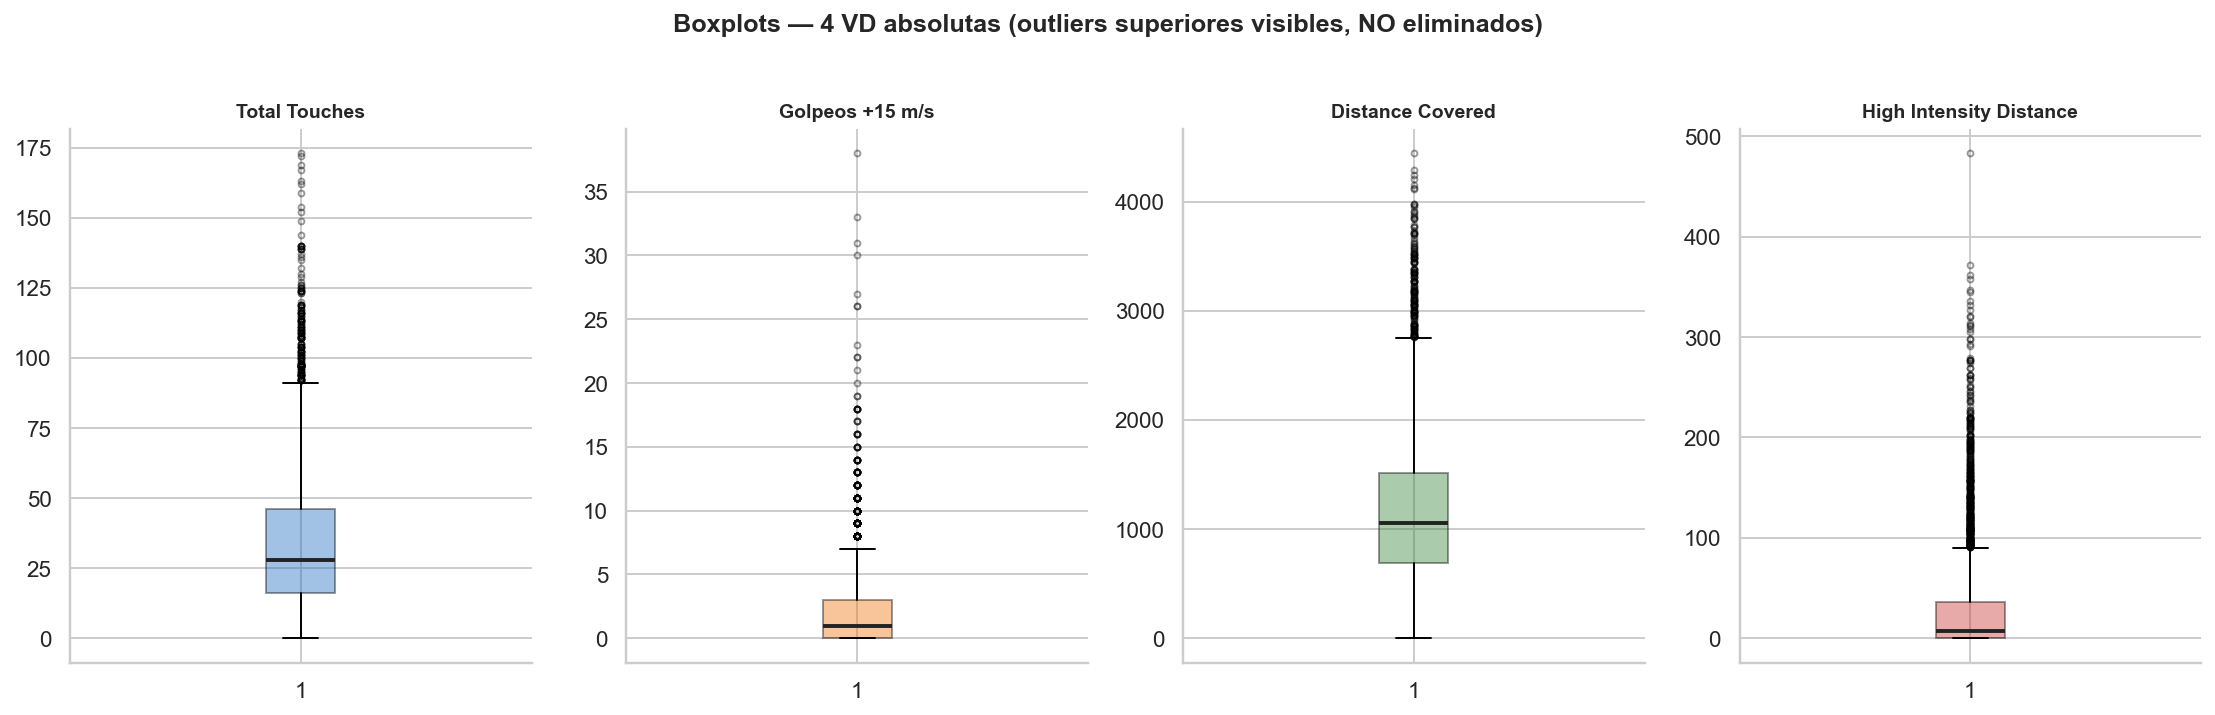

In [6]:
# ── 3.2 Boxplots de las 4 VD absolutas ──
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]

for ax, col, color in zip(axes, VD_ABS, colores):
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.4),
                    medianprops=dict(color="#222", lw=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(col.split("(")[0].strip() if "(" in col else col.split("[")[0].strip(),
                 fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Boxplots — 4 VD absolutas (outliers superiores visibles, NO eliminados)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Análisis de Golpeos +15 m/s (PassesOver15ms)

Variable con **alta proporción de ceros** por naturaleza (muchas tareas no implican golpeos potentes). Se analiza su distribución pero **no se usa como criterio de exclusión** salvo incoherencia evidente.

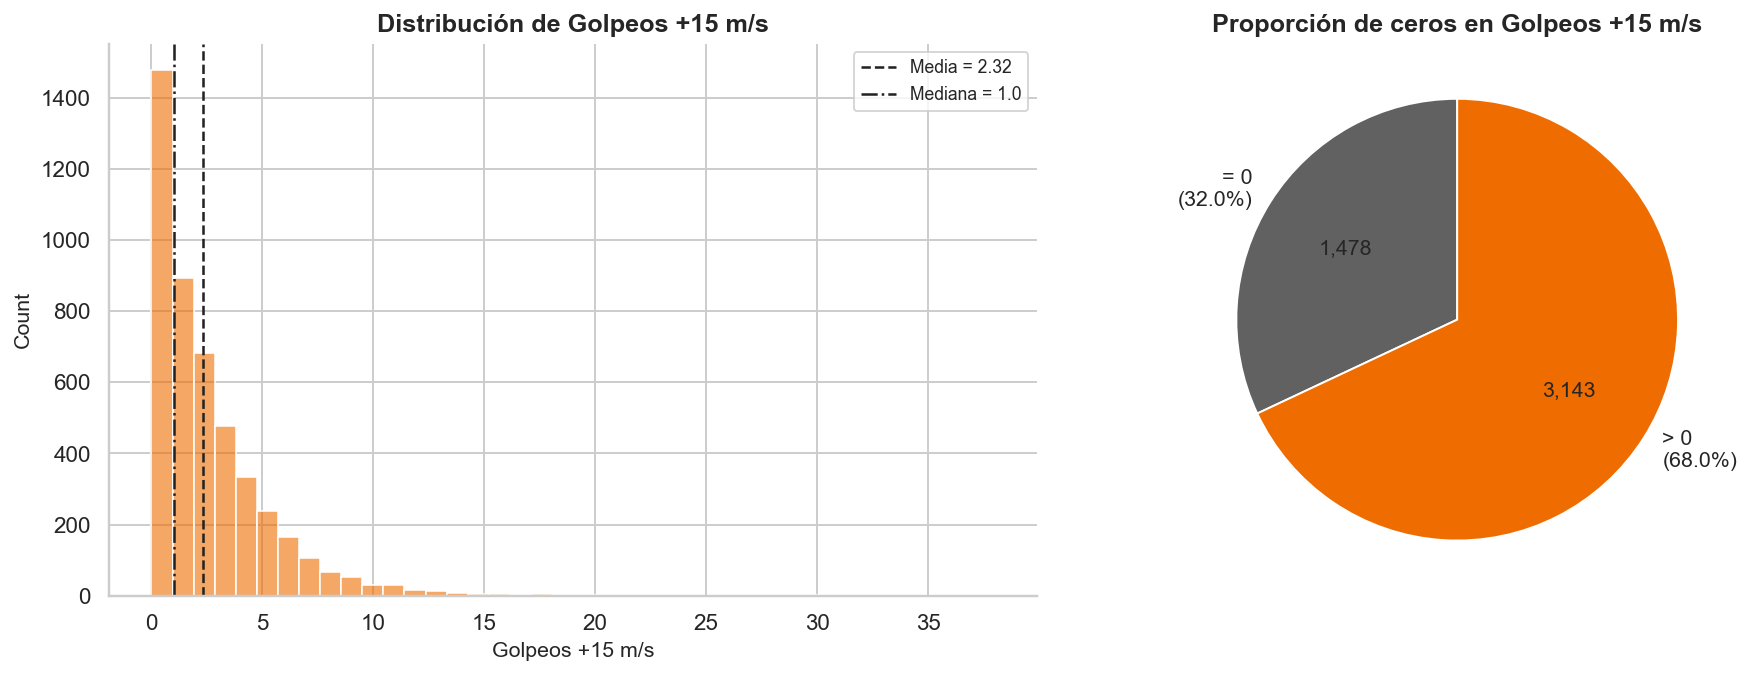


📊 Golpeos +15 m/s = 0: 1,478 / 4,621 (32.0%)
   → Esperado: muchas tareas no implican golpeos potentes.
   → NO se usa como criterio de exclusión.


In [7]:
# ── 4.1 Distribución y % de ceros de Golpeos +15 m/s ──
col_passes = COL["PassesOver15ms"]
n_ceros_passes = (df[col_passes] == 0).sum()
pct_ceros_passes = n_ceros_passes / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(df[col_passes], bins=40, color=PALETTE["naranja"], edgecolor="white",
             alpha=0.6, ax=axes[0])
axes[0].set_title("Distribución de Golpeos +15 m/s", fontweight="bold")
axes[0].set_xlabel("Golpeos +15 m/s")
axes[0].axvline(df[col_passes].mean(), color="#222", ls="--", lw=1.3,
                label=f"Media = {df[col_passes].mean():.2f}")
axes[0].axvline(df[col_passes].median(), color="#222", ls="-.", lw=1.3,
                label=f"Mediana = {df[col_passes].median():.1f}")
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# Proporción ceros vs no-ceros
valores = [n_ceros_passes, len(df) - n_ceros_passes]
etiquetas = [f"= 0\n({pct_ceros_passes:.1f}%)", f"> 0\n({100-pct_ceros_passes:.1f}%)"]
axes[1].pie(valores, labels=etiquetas, colors=[PALETTE["gris"], PALETTE["naranja"]],
            autopct=lambda p: f"{int(p/100*len(df)):,}", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Proporción de ceros en Golpeos +15 m/s", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n📊 Golpeos +15 m/s = 0: {n_ceros_passes:,} / {len(df):,} ({pct_ceros_passes:.1f}%)")
print(f"   → Esperado: muchas tareas no implican golpeos potentes.")
print(f"   → NO se usa como criterio de exclusión.")

## 5 · Análisis de High Intensity Distance (20 km/h)

Distancia a alta intensidad (> 5.5 m/s ≈ 20 km/h). Puede tener ceros legítimos (tareas técnicas sin desplazamiento intenso o sprints). Se analiza pero **no se usa como criterio principal de exclusión**.

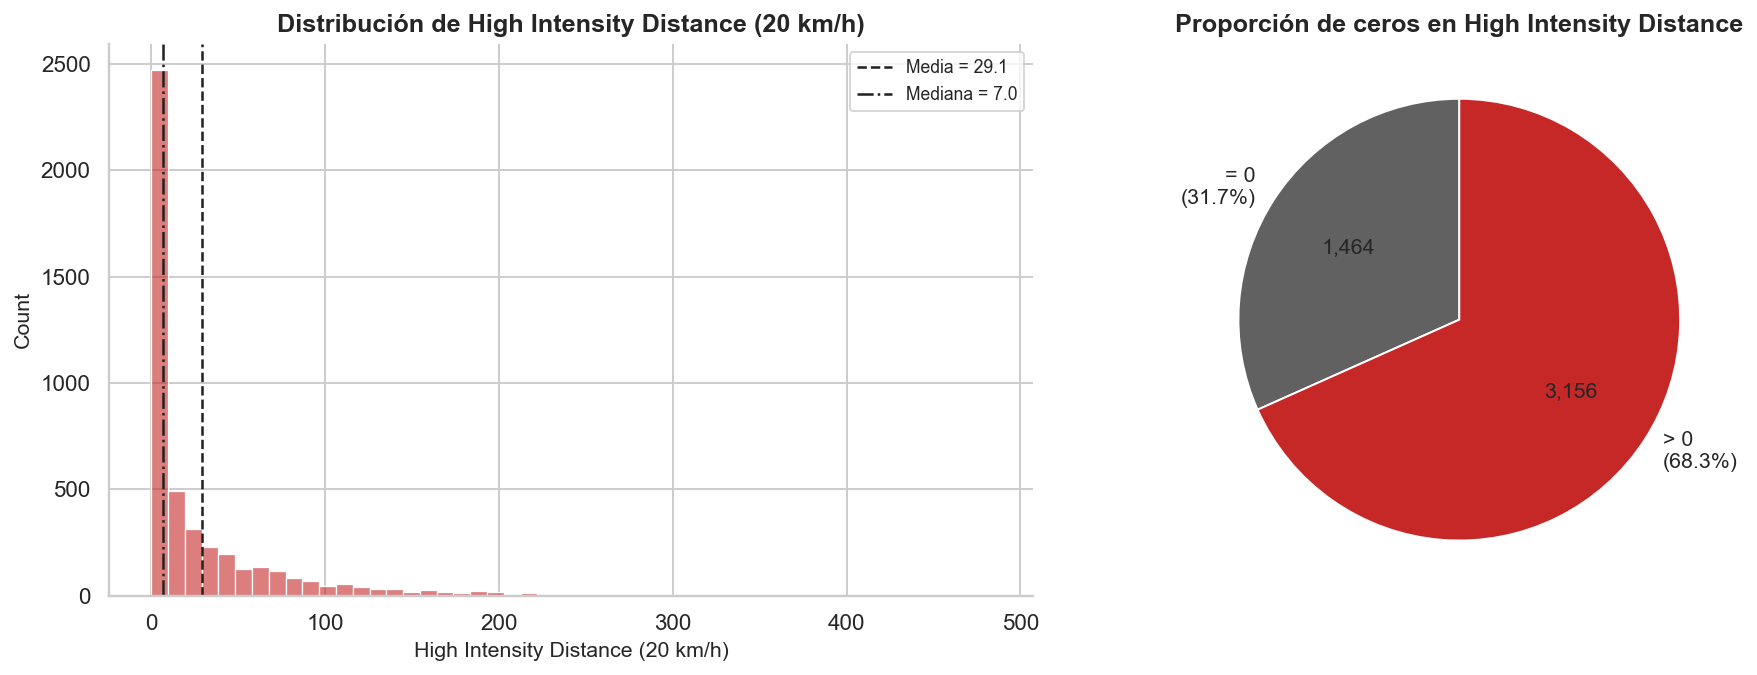


📊 High Intensity Distance (20 km/h) = 0: 1,464 / 4,621 (31.7%)
   → Esperado: no todas las tareas implican sprints (> 5.5 m/s ≈ 20 km/h).
   → NO se usa como criterio de exclusión.


In [8]:
# ── 5.1 Distribución y % de ceros de High Intensity Distance (20 km/h) ──
col_hid = COL["HIDCovered"]
n_ceros_hid = (df[col_hid] == 0).sum()
pct_ceros_hid = n_ceros_hid / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[col_hid], bins=50, color=PALETTE["rojo"], edgecolor="white",
             alpha=0.6, ax=axes[0])
axes[0].set_title("Distribución de High Intensity Distance (20 km/h)", fontweight="bold")
axes[0].set_xlabel("High Intensity Distance (20 km/h)")
axes[0].axvline(df[col_hid].mean(), color="#222", ls="--", lw=1.3,
                label=f"Media = {df[col_hid].mean():.1f}")
axes[0].axvline(df[col_hid].median(), color="#222", ls="-.", lw=1.3,
                label=f"Mediana = {df[col_hid].median():.1f}")
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

valores = [n_ceros_hid, len(df) - n_ceros_hid]
etiquetas = [f"= 0\n({pct_ceros_hid:.1f}%)", f"> 0\n({100-pct_ceros_hid:.1f}%)"]
axes[1].pie(valores, labels=etiquetas, colors=[PALETTE["gris"], PALETTE["rojo"]],
            autopct=lambda p: f"{int(p/100*len(df)):,}", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Proporción de ceros en High Intensity Distance", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n📊 High Intensity Distance (20 km/h) = 0: {n_ceros_hid:,} / {len(df):,} ({pct_ceros_hid:.1f}%)")
print(f"   → Esperado: no todas las tareas implican sprints (> 5.5 m/s ≈ 20 km/h).")
print(f"   → NO se usa como criterio de exclusión.")

## 6 · Distance Covered — Distribución y relación con las instancias excluidas

Se analiza la distribución de **Distance Covered**, se identifican instancias con valor 0 y se estudia cómo se comportan las instancias ya excluidas por el criterio de toques en las variables de distancia (absoluta y normalizada por minuto).

════════════════════════════════════════════════════════════
  PERCENTILES — Distance Covered (m)
════════════════════════════════════════════════════════════
0.01       6.2
0.05     249.0
0.10     382.0
0.25     687.0
0.50    1059.0
Name: valor, dtype: float64

🔑 Valores clave:
   Instancias con Distance = 0:  6 (0.13%)
   p05 = 249.0 m
   p10 = 382.0 m


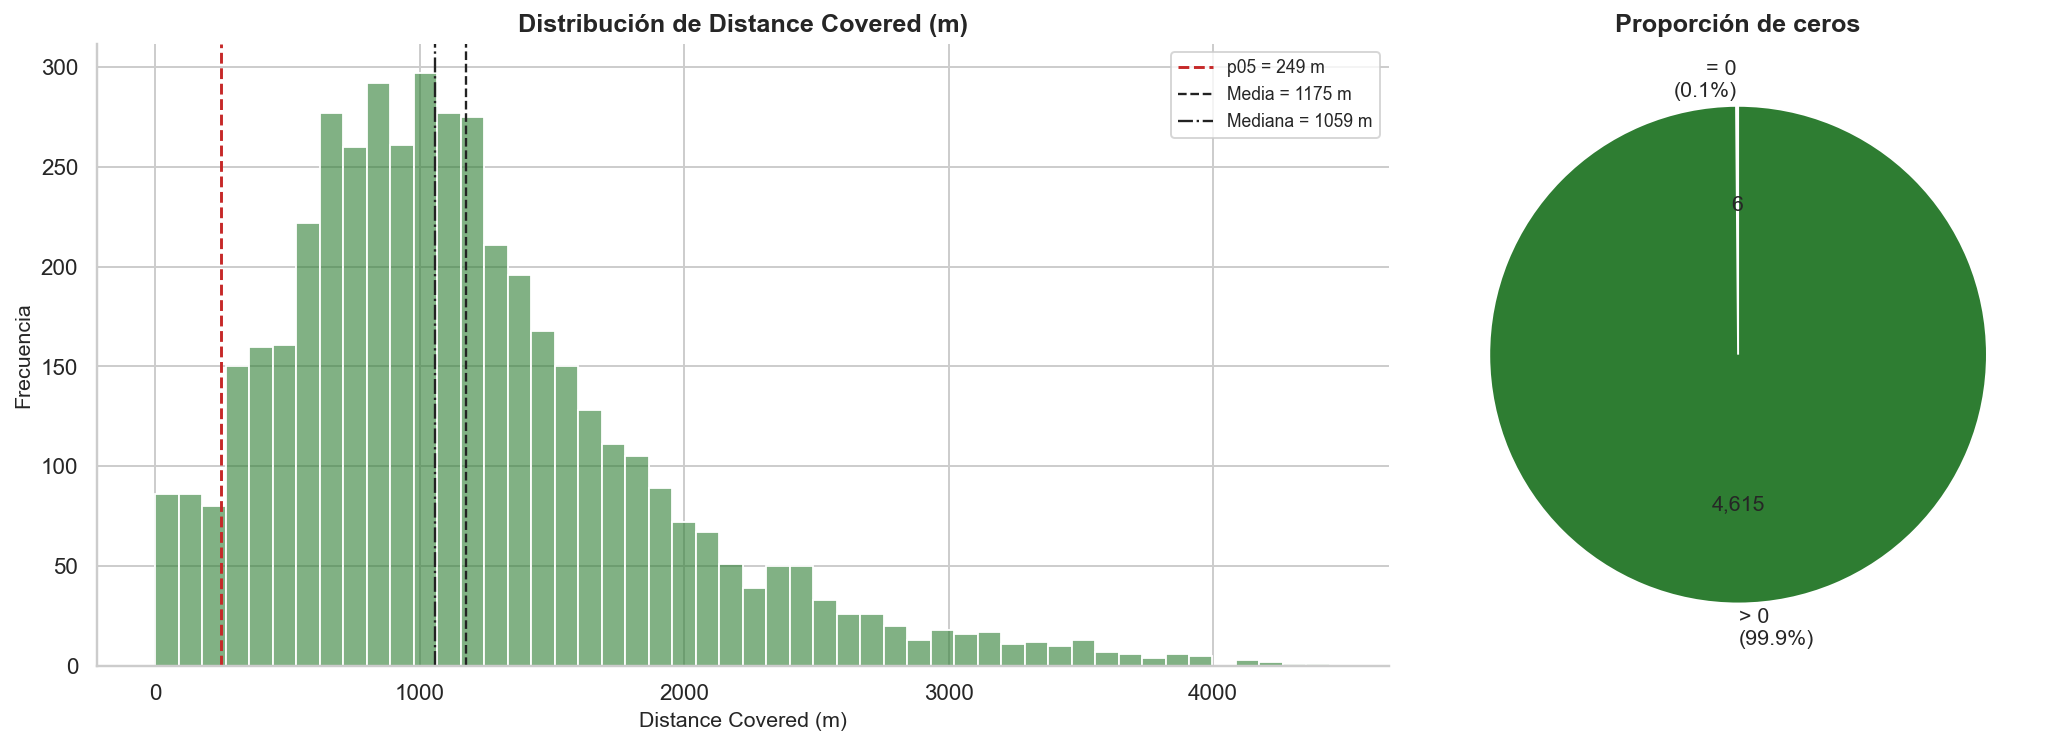

In [9]:
# ── 6.1 Distribución de Distance Covered: histograma, ceros, percentiles ──
col_dist    = COL["DistanceCovered"]
col_distmin = COL["DistPerMin"]

n_ceros_dist = (df[col_dist] == 0).sum()
pct_ceros_dist = n_ceros_dist / len(df) * 100
q05_dist = df[col_dist].quantile(0.05)
q10_dist = df[col_dist].quantile(0.10)

print("═" * 60)
print("  PERCENTILES — Distance Covered (m)")
print("═" * 60)
print(compute_percentiles(df[col_dist]))

print(f"\n🔑 Valores clave:")
print(f"   Instancias con Distance = 0:  {n_ceros_dist} ({pct_ceros_dist:.2f}%)")
print(f"   p05 = {q05_dist:.1f} m")
print(f"   p10 = {q10_dist:.1f} m")

# ── Histograma con p05 y media ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
sns.histplot(df[col_dist], bins=50, color=PALETTE["verde"],
             edgecolor="white", alpha=0.6, ax=ax)
ax.axvline(q05_dist, color=PALETTE["rojo"], ls="--", lw=1.5,
           label=f"p05 = {q05_dist:.0f} m")
ax.axvline(df[col_dist].mean(), color="#222", ls="--", lw=1.2,
           label=f"Media = {df[col_dist].mean():.0f} m")
ax.axvline(df[col_dist].median(), color="#222", ls="-.", lw=1.2,
           label=f"Mediana = {df[col_dist].median():.0f} m")
ax.set_title("Distribución de Distance Covered (m)", fontweight="bold")
ax.set_xlabel("Distance Covered (m)")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Pie chart: ceros vs no ceros
ax2 = axes[1]
if n_ceros_dist > 0:
    vals = [n_ceros_dist, len(df) - n_ceros_dist]
    lbls = [f"= 0\n({pct_ceros_dist:.1f}%)", f"> 0\n({100-pct_ceros_dist:.1f}%)"]
    ax2.pie(vals, labels=lbls, colors=[PALETTE["gris"], PALETTE["verde"]],
            autopct=lambda p: f"{int(p/100*len(df)):,}", startangle=90,
            textprops={"fontsize": 11})
    ax2.set_title("Proporción de ceros", fontweight="bold")
else:
    ax2.text(0.5, 0.5, f"No hay instancias\ncon Distance = 0",
             ha="center", va="center", fontsize=13, fontweight="bold",
             transform=ax2.transAxes)
    ax2.set_title("Proporción de ceros", fontweight="bold")
    ax2.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ── 6.1b Comprobación: ¿las instancias con Distance Covered = 0 fueron excluidas por toques? ──

mask_dist_cero = df[col_dist] == 0
n_dist_cero = mask_dist_cero.sum()

# ¿Cuántas de esas también cumplen el criterio de eliminación por toques?
n_dist_cero_y_elim = (mask_dist_cero & mask_no_part).sum()
n_dist_cero_no_elim = (mask_dist_cero & ~mask_no_part).sum()

print("═" * 65)
print("  COMPROBACIÓN: Instancias con Distance Covered = 0")
print("═" * 65)
print(f"\n  Total instancias con Distance = 0:  {n_dist_cero}")
print(f"  ─────────────────────────────────────────────")
print(f"  Eliminadas por criterio de toques:   {n_dist_cero_y_elim}  ({'✅ TODAS' if n_dist_cero_no_elim == 0 else f'⚠️ Quedan {n_dist_cero_no_elim} sin eliminar'})")
print(f"  NO eliminadas (permanecen):          {n_dist_cero_no_elim}")

if n_dist_cero_no_elim > 0:
    print(f"\n  ⚠️ Detalle de las {n_dist_cero_no_elim} instancias con Distance=0 NO eliminadas:")
    cols_mostrar = ["Player Name", COL["TotalTouches"], COL["TouchesPerMin"],
                    col_dist, col_distmin]
    cols_disponibles = [c for c in cols_mostrar if c in df.columns]
    display(df.loc[mask_dist_cero & ~mask_no_part, cols_disponibles])
else:
    print(f"\n  ✅ Todas las instancias con Distance Covered = 0 han sido")
    print(f"     excluidas por el criterio de toques (p05 conjunto).")
    print(f"     No es necesario un filtro adicional por distancia.")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  COMPROBACIÓN: Instancias con Distance Covered = 0
═════════════════════════════════════════════════════════════════

  Total instancias con Distance = 0:  6
  ─────────────────────────────────────────────
  Eliminadas por criterio de toques:   6  (✅ TODAS)
  NO eliminadas (permanecen):          0

  ✅ Todas las instancias con Distance Covered = 0 han sido
     excluidas por el criterio de toques (p05 conjunto).
     No es necesario un filtro adicional por distancia.
═════════════════════════════════════════════════════════════════


In [11]:
# ── 6.2 Relación: instancias excluidas por toques vs Distance Covered ──

# Perfil de Distance en eliminados vs conservados
dist_elim = df.loc[mask_no_part, col_dist]
dist_rest = df.loc[~mask_no_part, col_dist]
distmin_elim = df.loc[mask_no_part, col_distmin]
distmin_rest = df.loc[~mask_no_part, col_distmin]

# ¿Cuántos eliminados están también bajo p05 de distancia?
mask_dist_low = df[col_dist] < q05_dist
n_elim_bajo_p05_dist = (mask_no_part & mask_dist_low).sum()

q05_distmin = df[col_distmin].quantile(0.05)
mask_distmin_low = df[col_distmin] < q05_distmin
n_elim_bajo_p05_distmin = (mask_no_part & mask_distmin_low).sum()

print("═" * 65)
print("  RELACIÓN: Eliminados por toques vs Distance Covered")
print("═" * 65)
print(f"\n  Instancias eliminadas (criterio toques): {mask_no_part.sum()}")
print(f"\n  Distance Covered (m):")
print(f"    Media eliminados:    {dist_elim.mean():>8.1f} m")
print(f"    Media conservados:   {dist_rest.mean():>8.1f} m")
print(f"    Ratio elim/cons:     {dist_elim.mean()/dist_rest.mean():>8.3f}")
print(f"    Eliminados bajo p05 dist ({q05_dist:.0f} m): {n_elim_bajo_p05_dist}/{mask_no_part.sum()} ({n_elim_bajo_p05_dist/mask_no_part.sum()*100:.1f}%)")
print(f"\n  Distance Covered / min:")
print(f"    p05 Dist/min:        {q05_distmin:.2f} m/min")
print(f"    Media eliminados:    {distmin_elim.mean():>8.2f} m/min")
print(f"    Media conservados:   {distmin_rest.mean():>8.2f} m/min")
print(f"    Ratio elim/cons:     {distmin_elim.mean()/distmin_rest.mean():>8.3f}")
print(f"    Eliminados bajo p05 dist/min:  {n_elim_bajo_p05_distmin}/{mask_no_part.sum()} ({n_elim_bajo_p05_distmin/mask_no_part.sum()*100:.1f}%)")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  RELACIÓN: Eliminados por toques vs Distance Covered
═════════════════════════════════════════════════════════════════

  Instancias eliminadas (criterio toques): 175

  Distance Covered (m):
    Media eliminados:       254.2 m
    Media conservados:     1211.0 m
    Ratio elim/cons:        0.210
    Eliminados bajo p05 dist (249 m): 122/175 (69.7%)

  Distance Covered / min:
    p05 Dist/min:        27.60 m/min
    Media eliminados:       29.08 m/min
    Media conservados:      79.17 m/min
    Ratio elim/cons:        0.367
    Eliminados bajo p05 dist/min:  111/175 (63.4%)
═════════════════════════════════════════════════════════════════


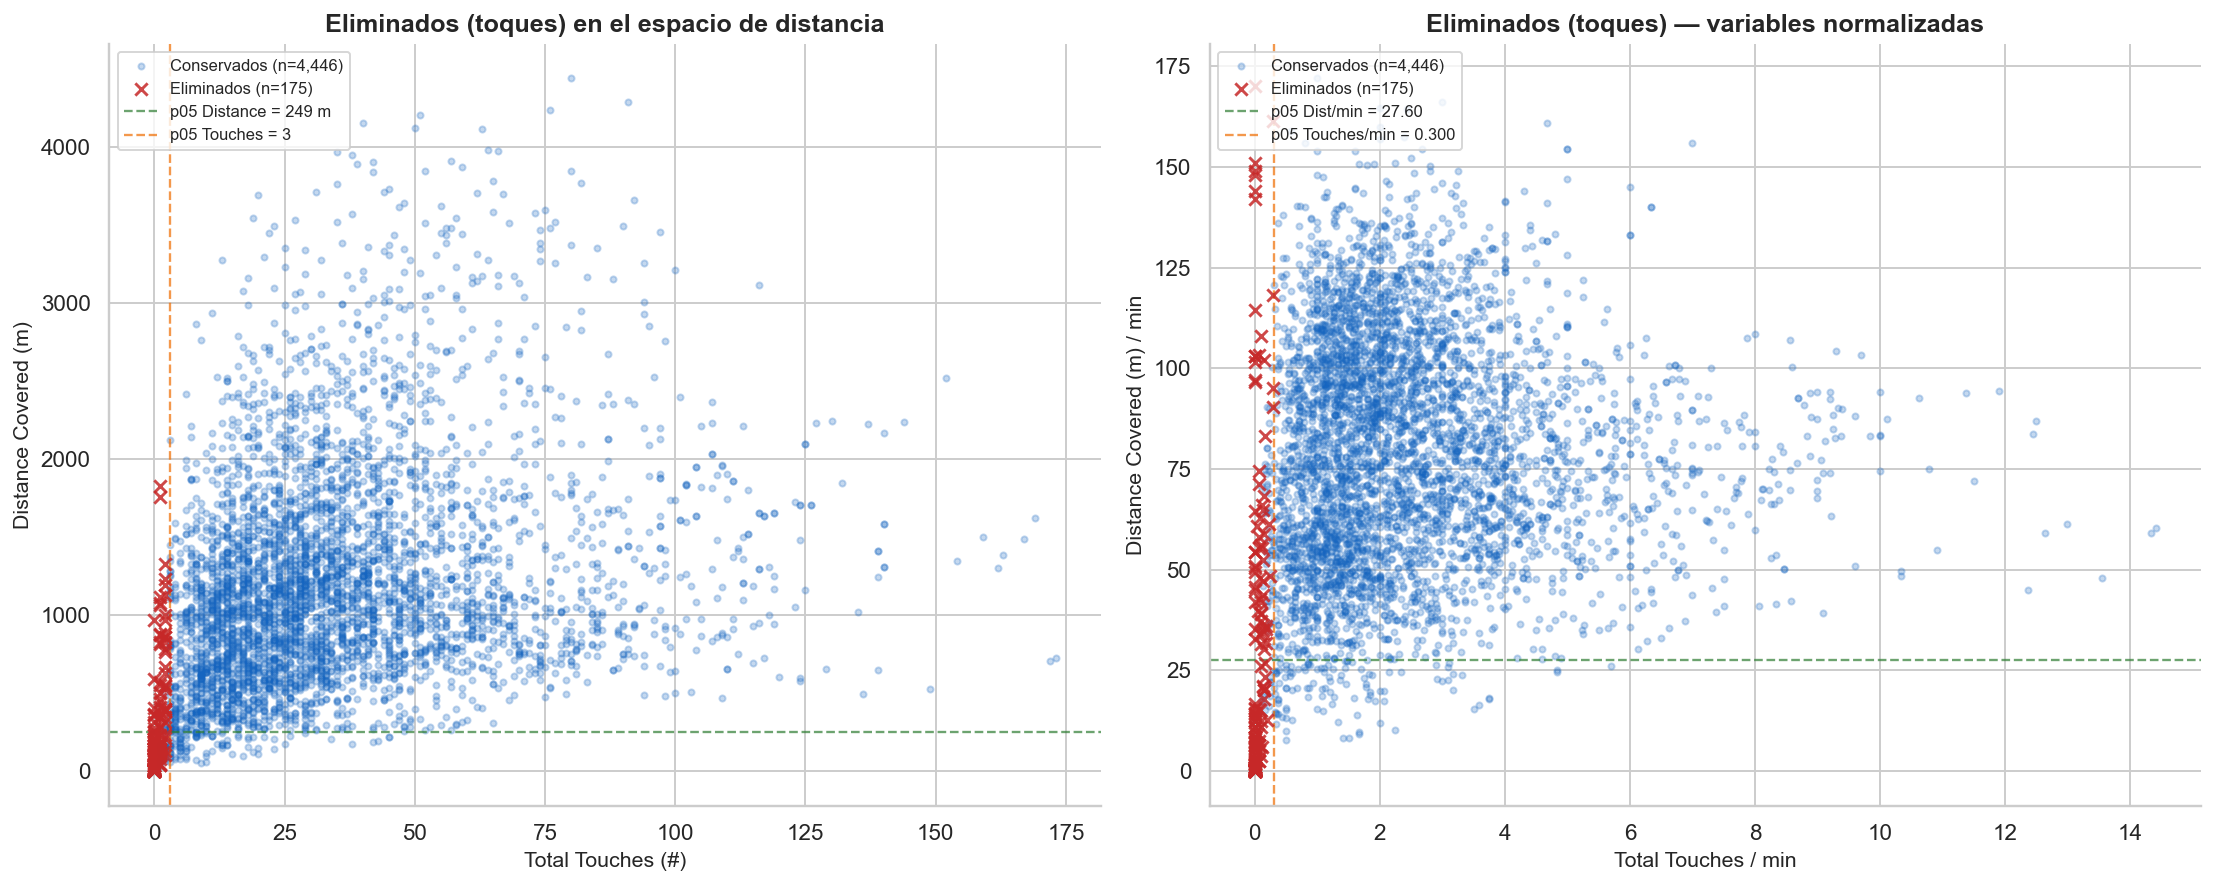


💡 La mayoría de instancias eliminadas por toques se concentran
   en la zona baja de distancia, confirmando coherencia del criterio.


In [12]:
# ── 6.3 Visualización: eliminados por toques en el espacio de distancia ──

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --- Panel 1: Distance Covered (m) vs Total Touches ---
ax = axes[0]
ax.scatter(df.loc[~mask_no_part, COL["TotalTouches"]],
           df.loc[~mask_no_part, col_dist],
           s=10, alpha=0.25, color=PALETTE["azul"],
           label=f"Conservados (n={( ~mask_no_part).sum():,})", zorder=2)
ax.scatter(df.loc[mask_no_part, COL["TotalTouches"]],
           df.loc[mask_no_part, col_dist],
           s=40, alpha=0.85, color=PALETTE["rojo"], marker="x", linewidths=1.5,
           label=f"Eliminados (n={mask_no_part.sum()})", zorder=3)
ax.axhline(q05_dist, color=PALETTE["verde"], ls="--", lw=1.2, alpha=0.7,
           label=f"p05 Distance = {q05_dist:.0f} m")
ax.axvline(q05_touches, color=PALETTE["naranja"], ls="--", lw=1.2, alpha=0.7,
           label=f"p05 Touches = {q05_touches:.0f}")
ax.set_xlabel("Total Touches (#)", fontsize=11)
ax.set_ylabel("Distance Covered (m)", fontsize=11)
ax.set_title("Eliminados (toques) en el espacio de distancia", fontweight="bold")
ax.legend(fontsize=8.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

# --- Panel 2: Distance Covered/min vs Touches/min ---
ax2 = axes[1]
ax2.scatter(df.loc[~mask_no_part, COL["TouchesPerMin"]],
            df.loc[~mask_no_part, col_distmin],
            s=10, alpha=0.25, color=PALETTE["azul"],
            label=f"Conservados (n={( ~mask_no_part).sum():,})", zorder=2)
ax2.scatter(df.loc[mask_no_part, COL["TouchesPerMin"]],
            df.loc[mask_no_part, col_distmin],
            s=40, alpha=0.85, color=PALETTE["rojo"], marker="x", linewidths=1.5,
            label=f"Eliminados (n={mask_no_part.sum()})", zorder=3)
ax2.axhline(q05_distmin, color=PALETTE["verde"], ls="--", lw=1.2, alpha=0.7,
            label=f"p05 Dist/min = {q05_distmin:.2f}")
ax2.axvline(q05_tpm, color=PALETTE["naranja"], ls="--", lw=1.2, alpha=0.7,
            label=f"p05 Touches/min = {q05_tpm:.3f}")
ax2.set_xlabel("Total Touches / min", fontsize=11)
ax2.set_ylabel("Distance Covered (m) / min", fontsize=11)
ax2.set_title("Eliminados (toques) — variables normalizadas", fontweight="bold")
ax2.legend(fontsize=8.5, loc="upper left")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n💡 La mayoría de instancias eliminadas por toques se concentran")
print(f"   en la zona baja de distancia, confirmando coherencia del criterio.")

## 7 · Aplicación del filtro y análisis detallado del impacto

Se aplica el criterio de **p05 conjunto en toques** (Escenario A) por ser:

1. **Conservador**: exige que ambas condiciones se cumplan simultáneamente (AND).
2. **Interpretable**: un jugador sin toques ni tasa de toques no participó activamente.
3. **Independiente de la dimensión física**: no penaliza tareas técnicas sin desplazamiento.
4. **Coherente con distancia**: la sección anterior confirma que los eliminados también concentran valores bajos de distancia.

In [13]:
# ── 7.1 Aplicación del Escenario A ──
mask_A = mask_no_part   # alias para claridad en secciones posteriores
df_antes = df.copy()
df_clean = df[~mask_A].reset_index(drop=True)

n_elim = len(df_antes) - len(df_clean)
pct_elim = n_elim / len(df_antes) * 100

print("═" * 60)
print("  APLICACIÓN DEL FILTRO — Escenario A (toques p05 conjunto)")
print("═" * 60)
print(f"  Instancias antes:     {len(df_antes):,}")
print(f"  Instancias eliminadas:{n_elim:>6}  ({pct_elim:.2f}%)")
print(f"  Instancias después:   {len(df_clean):,}")
print("═" * 60)

════════════════════════════════════════════════════════════
  APLICACIÓN DEL FILTRO — Escenario A (toques p05 conjunto)
════════════════════════════════════════════════════════════
  Instancias antes:     4,621
  Instancias eliminadas:   175  (3.79%)
  Instancias después:   4,446
════════════════════════════════════════════════════════════


In [14]:
# ── 7.2 Tabla antes / después ──
comparacion = summarize_before_after(df_antes, df_clean, VD_ALL)
display(comparacion)

N    Media      SD  CV (%)
Variable                                Fase                                  
Total Touches (#)                       Antes    4621    34.15   25.73   75.35
                                        Después  4446    35.47   25.34   71.43
Golpeos +15 m/s                         Antes    4621     2.32    2.99  129.09
                                        Después  4446     2.41    3.02  125.30
Distance Covered (m)                    Antes    4621  1174.75  705.01   60.01
                                        Después  4446  1210.99  690.70   57.04
High Intensity Distance (20 km/h)       Antes    4621    29.07   49.31  169.62
                                        Después  4446    29.54   49.60  167.94
Total Touches / min                     Antes    4621     2.40    1.80   75.26
                                        Después  4446     2.49    1.78   71.36
Golpeos +15 m/s / min                   Antes    4621     0.16    0.22  139.43
                                        Después  4446     0.16    0.22  135.61
Distance Covered (m) / min              Antes    4621    77.27   30.25   39.14
                                        Después  4446    79.17   28.21   35.64
High Intensity Distance (20 km/h) / min Antes    4621     1.94    3.89  200.97
                                        Después  4446     1.86    3.20  172.40

In [15]:
# ── 7.3 Detalle: perfil de los eliminados en cada variable ──

# Tabla resumen: media, mediana, min, max de eliminados vs conservados
perfil_filas = []
for col in VD_ALL:
    s_elim = df_antes.loc[mask_A, col]
    s_cons = df_clean[col]
    perfil_filas.append({
        "Variable": col,
        "Media (elim)": round(s_elim.mean(), 2),
        "Mediana (elim)": round(s_elim.median(), 2),
        "Max (elim)": round(s_elim.max(), 2),
        "Media (cons)": round(s_cons.mean(), 2),
        "Mediana (cons)": round(s_cons.median(), 2),
        "Ratio medias": round(s_elim.mean() / s_cons.mean(), 4) if s_cons.mean() != 0 else 0,
    })

df_perfil = pd.DataFrame(perfil_filas)
display(df_perfil)

print("\n💡 Ratios << 1 confirman que los eliminados tienen valores residuales en todas las VD.")

,Variable,Media (elim),Mediana (elim),Max (elim),Media (cons),Mediana (cons),Ratio medias
0,Total Touches (#),0.52,0.0,2.00,35.47,29.00,0.0147
1,Golpeos +15 m/s,0.06,0.0,2.00,2.41,2.00,0.0261
2,Distance Covered (m),254.18,126.0,1826.00,1210.99,1087.00,0.2099
3,High Intensity Distance (20 km/h),17.28,0.0,190.00,29.54,8.00,0.5851
4,Total Touches / min,0.04,0.0,0.29,2.49,2.04,0.0179
5,Golpeos +15 m/s / min,0.01,0.0,0.18,0.16,0.11,0.0321
6,Distance Covered (m) / min,29.08,10.9,170.00,79.17,78.38,0.3674
7,High Intensity Distance (20 km/h) / min,3.94,0.0,67.00,1.86,0.56,2.1232



💡 Ratios << 1 confirman que los eliminados tienen valores residuales en todas las VD.


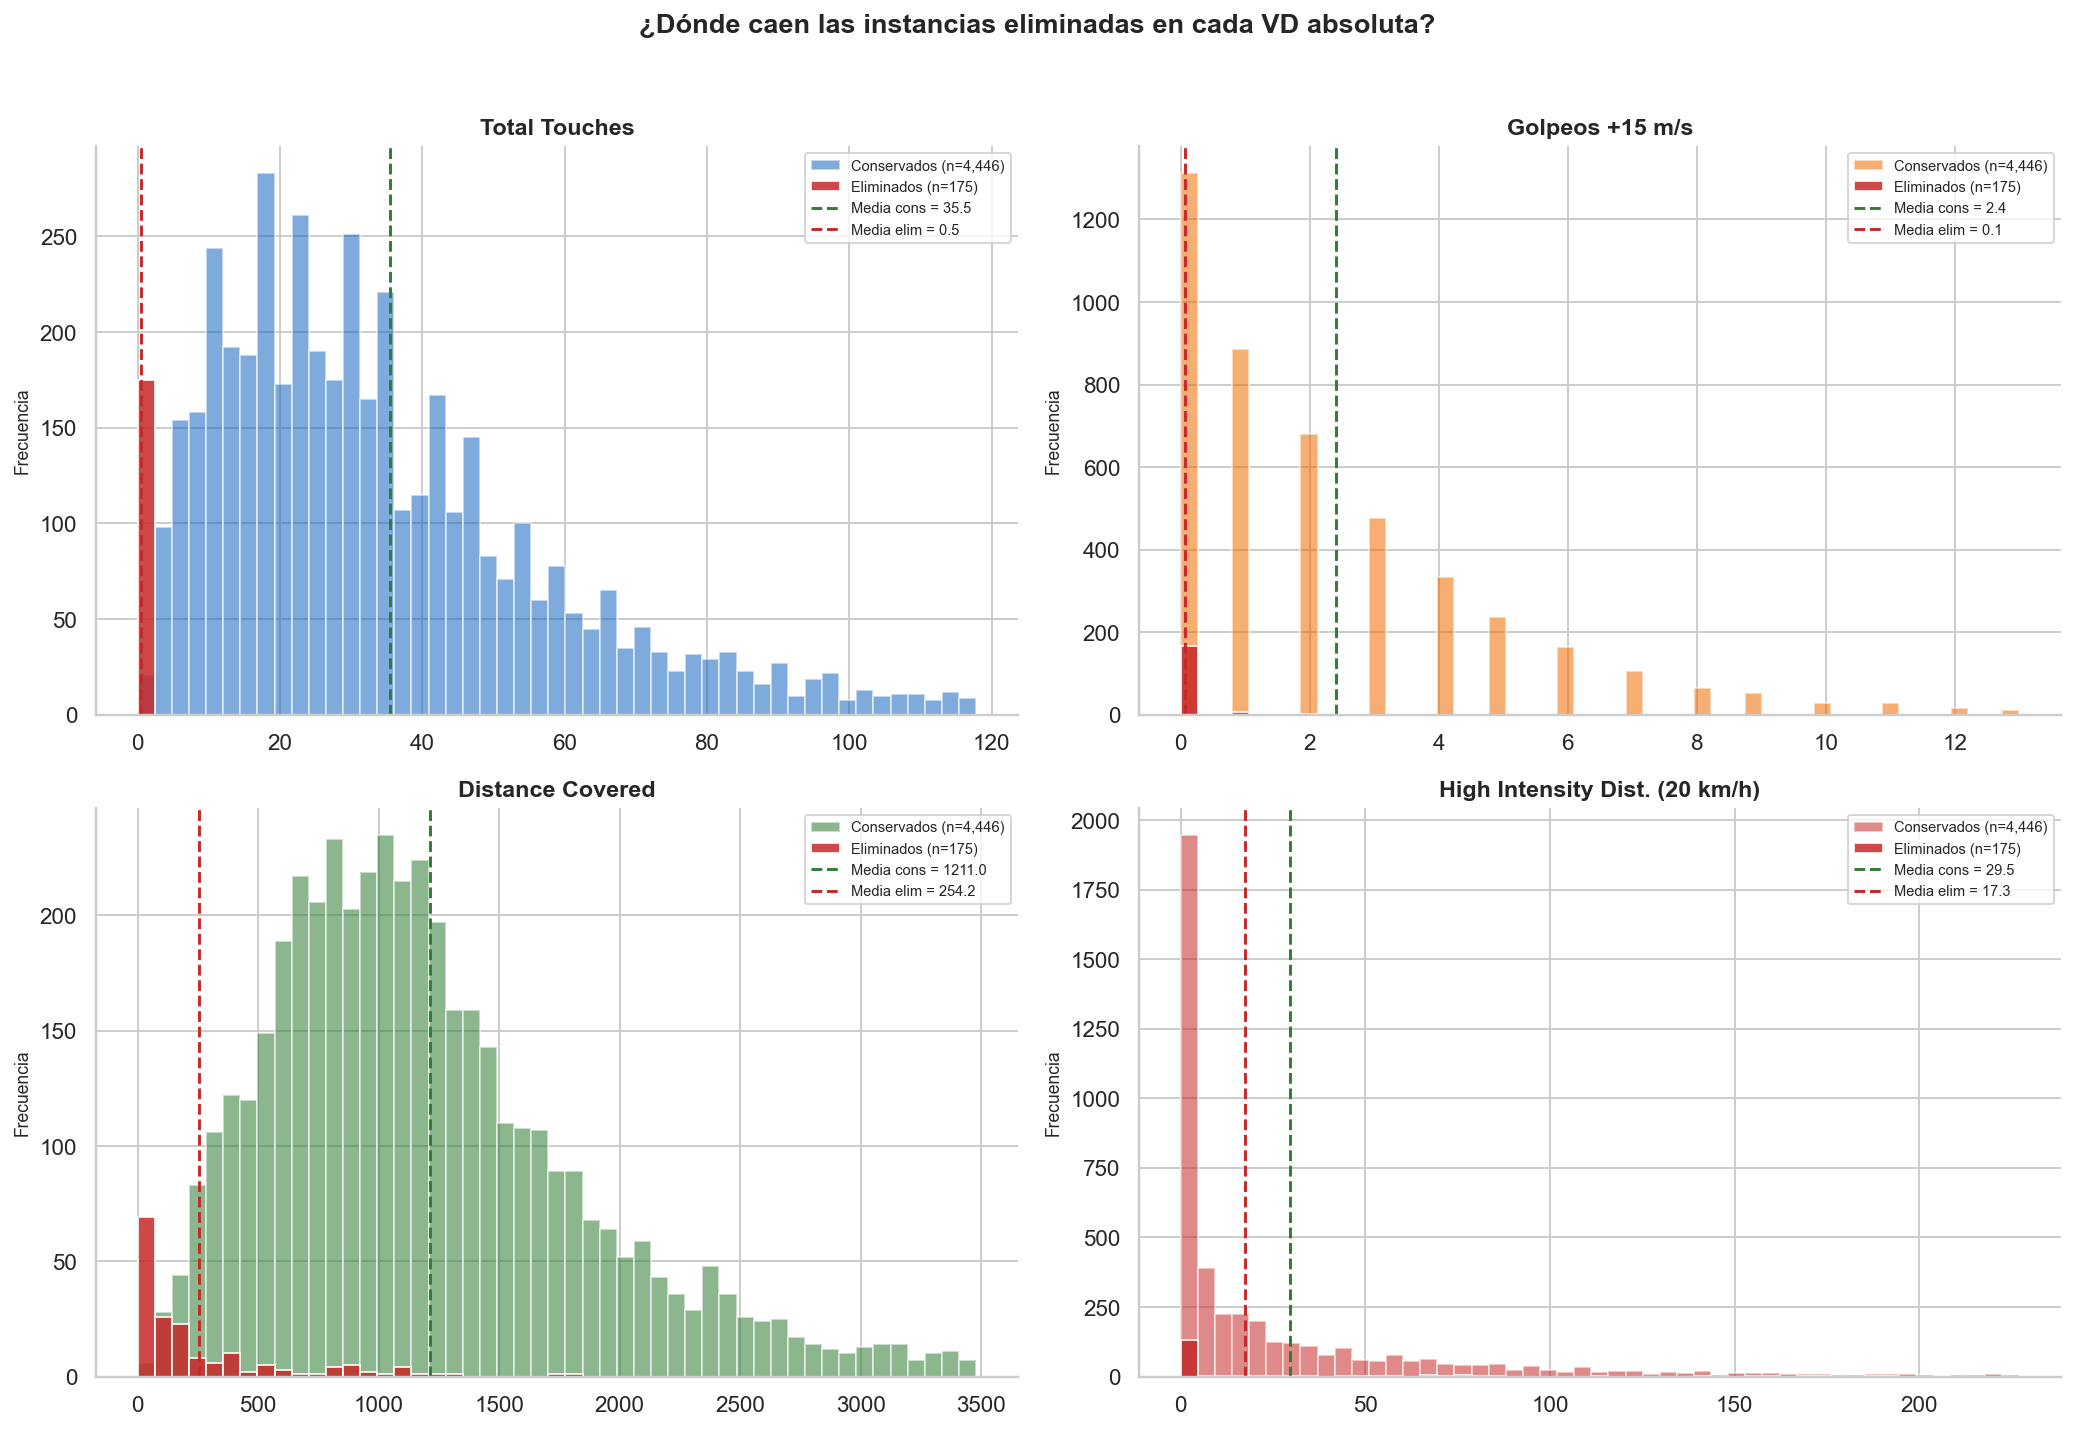

In [16]:
# ── 7.4 Histogramas: distribución total con eliminados resaltados (4 VD absolutas) ──

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]
nombres_cortos = ["Total Touches", "Golpeos +15 m/s", "Distance Covered", "High Intensity Dist. (20 km/h)"]

for i, (col, color, nombre) in enumerate(zip(VD_ABS, colores, nombres_cortos)):
    ax = axes[i]
    s_cons = df_clean[col]
    s_elim = df_antes.loc[mask_A, col]

    # Calcular bins comunes
    all_vals = df_antes[col]
    bins = np.linspace(all_vals.min(), all_vals.quantile(0.99), 50)

    # Histograma conservados
    ax.hist(s_cons, bins=bins, alpha=0.55, color=color,
            edgecolor="white", label=f"Conservados (n={len(s_cons):,})")
    # Histograma eliminados — apilado encima
    ax.hist(s_elim, bins=bins, alpha=0.85, color=PALETTE["rojo"],
            edgecolor="white", label=f"Eliminados (n={len(s_elim)})")

    # Líneas de referencia — colores fijos para distinguir
    ax.axvline(s_cons.mean(), color=PALETTE["verde"], ls="--", lw=1.5,
               label=f"Media cons = {s_cons.mean():.1f}")
    ax.axvline(s_elim.mean(), color=PALETTE["rojo"], ls="--", lw=1.5,
               label=f"Media elim = {s_elim.mean():.1f}")

    ax.set_title(nombre, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("¿Dónde caen las instancias eliminadas en cada VD absoluta?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

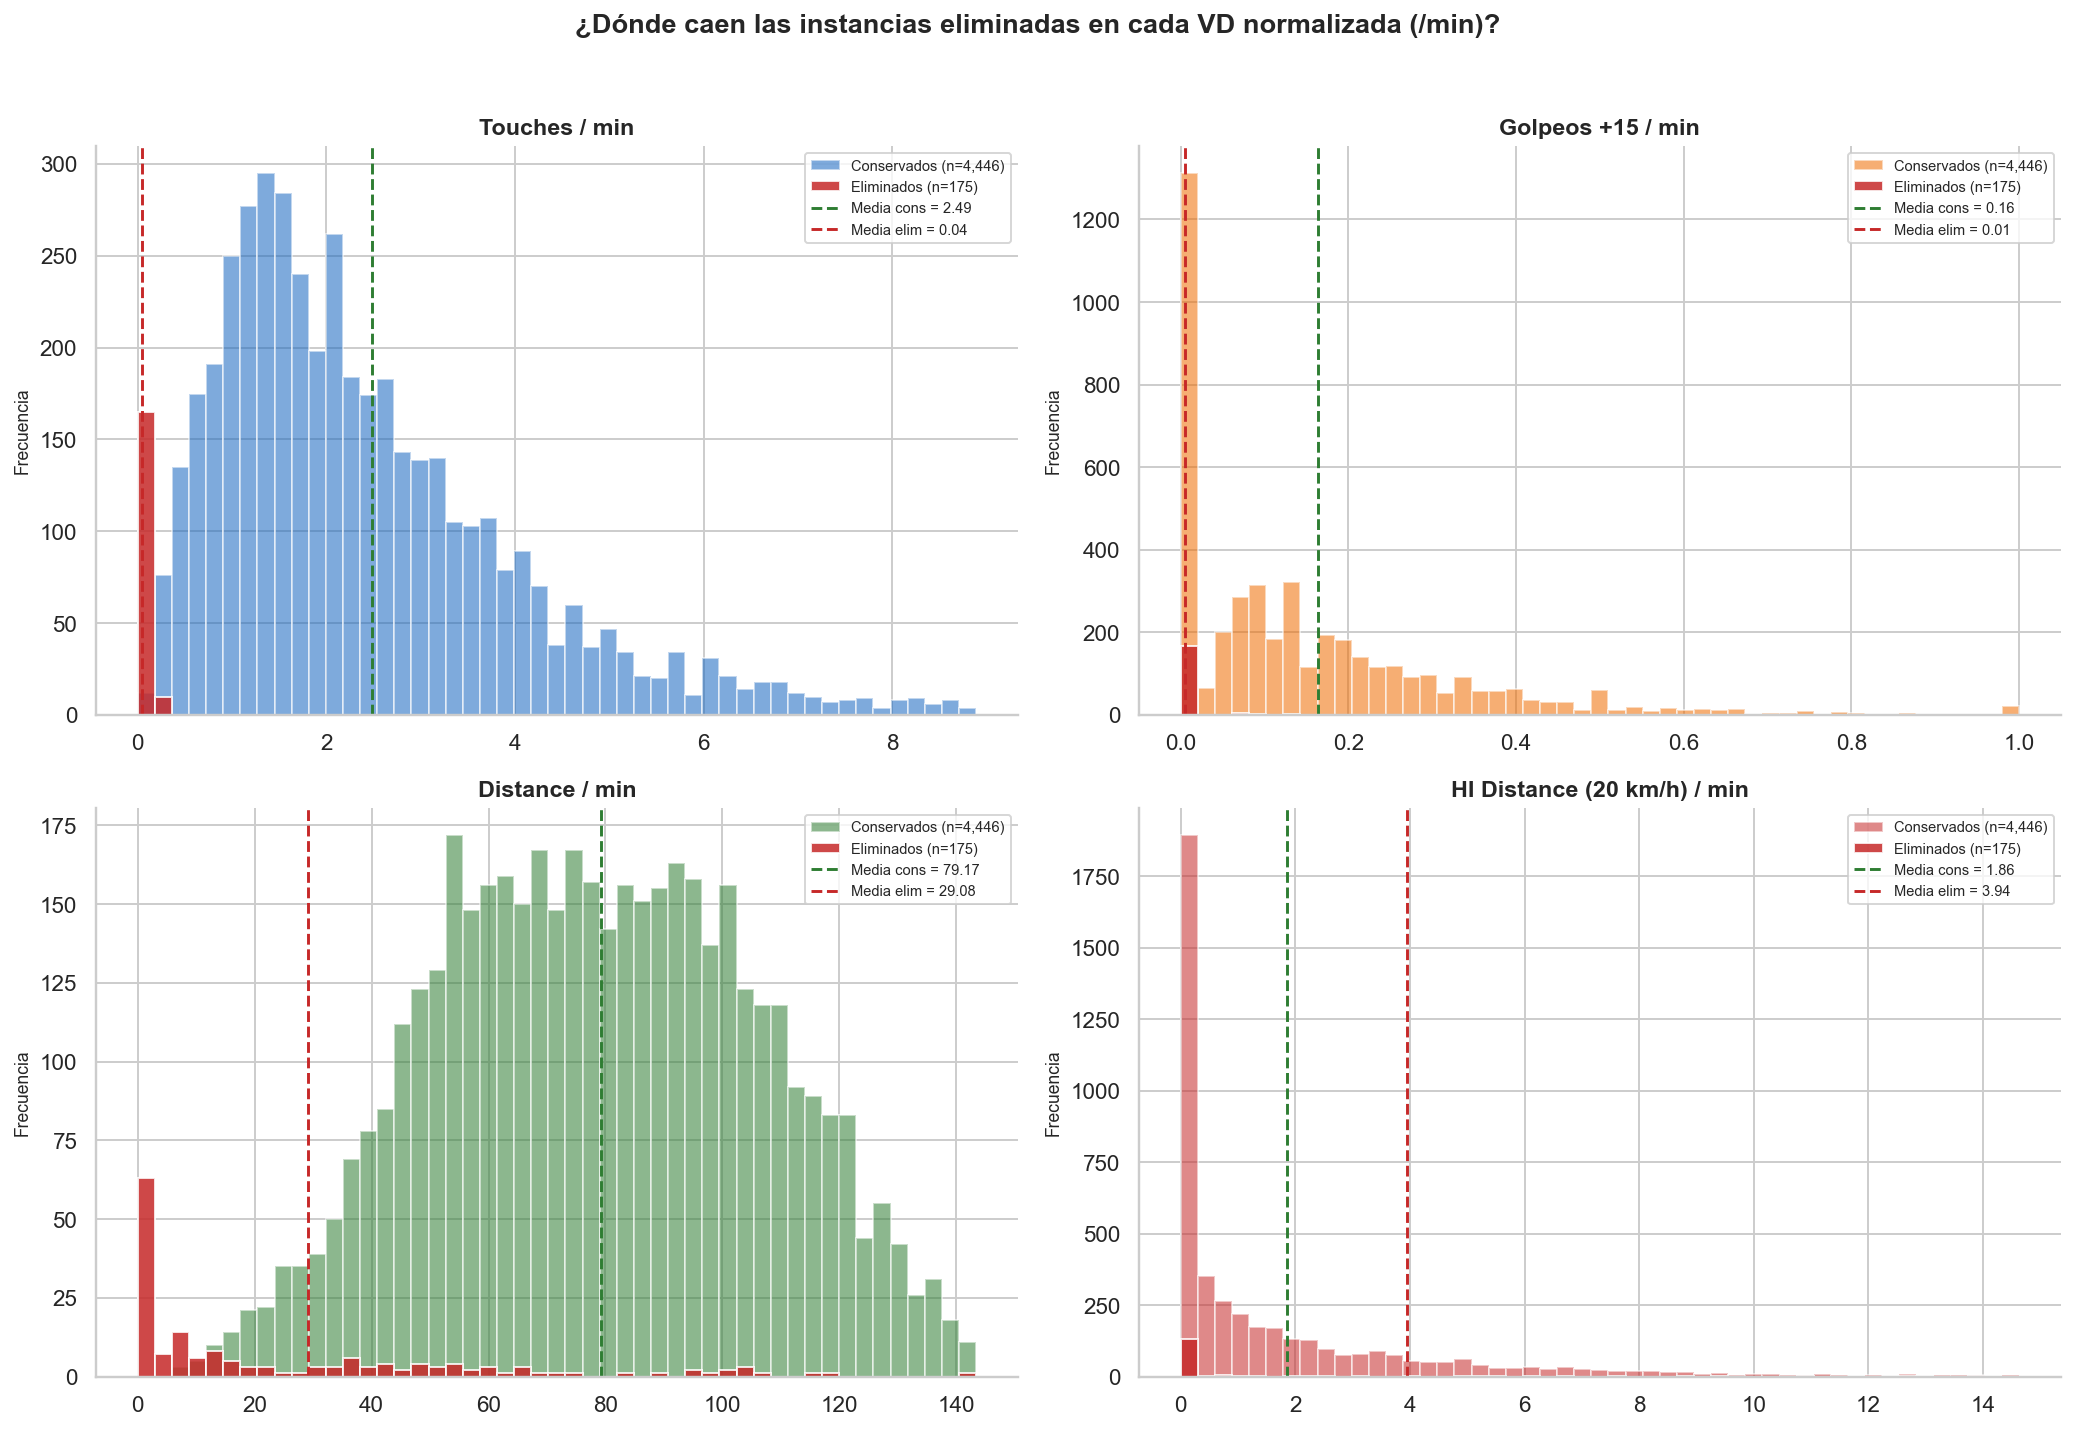

In [17]:
# ── 7.5 Histogramas: distribución total con eliminados resaltados (4 VD normalizadas) ──

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]
nombres_min = ["Touches / min", "Golpeos +15 / min", "Distance / min", "HI Distance (20 km/h) / min"]

for i, (col, color, nombre) in enumerate(zip(VD_MIN, colores, nombres_min)):
    ax = axes[i]
    s_cons = df_clean[col]
    s_elim = df_antes.loc[mask_A, col]

    all_vals = df_antes[col]
    bins = np.linspace(all_vals.min(), all_vals.quantile(0.99), 50)

    ax.hist(s_cons, bins=bins, alpha=0.55, color=color,
            edgecolor="white", label=f"Conservados (n={len(s_cons):,})")
    ax.hist(s_elim, bins=bins, alpha=0.85, color=PALETTE["rojo"],
            edgecolor="white", label=f"Eliminados (n={len(s_elim)})")

    ax.axvline(s_cons.mean(), color=PALETTE["verde"], ls="--", lw=1.5,
               label=f"Media cons = {s_cons.mean():.2f}")
    ax.axvline(s_elim.mean(), color=PALETTE["rojo"], ls="--", lw=1.5,
               label=f"Media elim = {s_elim.mean():.2f}")

    ax.set_title(nombre, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("¿Dónde caen las instancias eliminadas en cada VD normalizada (/min)?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8 · Exportación y resumen final

In [18]:
# ── 8.1 Exportación a Matriz_V3.xlsx ──
ruta_salida = "../Datos/Matriz_V3.xlsx"
df_clean.to_excel(ruta_salida, index=False)

print(f"✅ Dataset limpio exportado → {ruta_salida}")
print(f"   {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")

✅ Dataset limpio exportado → ../Datos/Matriz_V3.xlsx
   4,446 filas × 19 columnas


---

## Justificación metodológica

### Criterio aplicado

Se excluyeron instancias que presentaban **simultáneamente** valores por debajo del percentil 5 en **Total Touches (#)** y **Total Touches / min**. Este criterio identifica registros de **no participación o participación residual** en la tarea.

### Desglose del criterio

- Instancias bajo p05 en Total Touches solamente → no se eliminan (puede ser tarea corta con buen ritmo).
- Instancias bajo p05 en Touches/min solamente → no se eliminan (puede ser tarea larga con bajo ritmo pero participación real).
- Instancias bajo p05 en **AMBAS** → se eliminan (participación mínima absoluta y relativa).

### ¿Por qué este enfoque?

1. **Conservador y reproducible**: los percentiles se calculan dinámicamente. La conjunción (AND, no OR) minimiza falsos positivos.

2. **Basado en la dimensión técnica**: la participación en fútbol se manifiesta a través del contacto con el balón. Sin toques ni tasa mínima → no participación activa.

3. **Coherencia con Distance Covered**: los eliminados por toques también concentran valores muy bajos de distancia (ratio << 1), validando la coherencia del criterio sin necesidad de un filtro independiente por distancia.

4. **No se eliminan outliers superiores**: representan rendimiento extremo legítimo, fundamental para ANOVA, GLMM e ICC.

5. **Variables no usadas como criterio de exclusión**:
   - **Golpeos +15 m/s**: alta proporción natural de ceros. No indica no participación.
   - **High Intensity Distance (20 km/h)**: ceros legítimos en tareas sin sprints (> 5.5 m/s ≈ 20 km/h). No indica no participación.

### Compatibilidad con análisis posteriores

- **ANOVA / modelos lineales**: reduce ruido, mejora estimación de efectos fijos.
- **GLMM**: mantiene la estructura jerárquica (jugador dentro de sesión/fase).
- **ICC**: preserva variabilidad inter-sujeto al eliminar registros espurios.

### Resumen numérico

| Métrica | Antes | Después |
|:---|:---:|:---:|
| N instancias | 4 621 | 4 446 |
| Criterio | — | p05 conjunto (TotalTouches ∧ Touches/min) |
| Outliers superiores | Detectados | **No eliminados** |